# T06: Hypothesis Testing and Regression Modelling
## ADA2026 — Advanced Data Analytics (BI203)

---

### **B1: One-Sample Mean Test: Average Days Between Orders**

**Research Question :**
Does the average number of days between customer orders differ from 7 days?

**Step 1 : Define the Parameter**

µ = the true mean number of days between customer orders for
all Instacart customers.


**Step 2 : State the Hypotheses:**
- H₀: µ = 7 (the average reorder interval is 7 days)
- Hₐ: µ ≠ 7 (the average reorder interval is not 7 days)
This is a **two-tailed test** at α = 0.05.


**Step 3 : Identify the Appropriate Test**

We use a **one-sample t-test** because:
- The population standard deviation (σ) is unknown
- We are estimating it from the sample standard deviation (s)
- Although the sample is large, the t-test is still appropriate
  and produces reliable results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

interim_path = '/content/drive/MyDrive/ADA2026_Instacart_Project/Data/Interim/'
orders = pd.read_csv(interim_path + 'orders_interim.csv')
order_products = pd.read_csv(interim_path + 'order_products_interim.csv')

print("Data loaded successfully ✅")
print(f"Orders shape: {orders.shape}")

Mounted at /content/drive
Data loaded successfully ✅
Orders shape: (3421083, 7)


In [2]:
# Prepare data
data = orders['days_since_prior_order'].dropna()

# Summary statistics
sample_mean = data.mean()
sample_std = data.std()
n = len(data)
mu_0 = 7  # hypothesised mean

# Manual t-statistic
t_stat = (sample_mean - mu_0) / (sample_std / np.sqrt(n))

print("=== Manual Calculation ===")
print(f"Sample Mean (X̄): {sample_mean:.4f}")
print(f"Sample Std Dev (s): {sample_std:.4f}")
print(f"Sample Size (n): {n:,}")
print(f"Hypothesised Mean (µ₀): {mu_0}")
print(f"Standard Error (SE): {sample_std / np.sqrt(n):.6f}")
print(f"Manual t-statistic: {t_stat:.4f}")

t_stat_scipy, p_value = stats.ttest_1samp(data, popmean=7)

print("\n=== SciPy Verification ===")
print(f"SciPy t-statistic: {t_stat_scipy:.4f}")
print(f"p-value: {p_value}")


=== Manual Calculation ===
Sample Mean (X̄): 11.1148
Sample Std Dev (s): 9.2067
Sample Size (n): 3,214,874
Hypothesised Mean (µ₀): 7
Standard Error (SE): 0.005135
Manual t-statistic: 801.3621

=== SciPy Verification ===
SciPy t-statistic: 801.3621
p-value: 0.0


In [3]:
# Decision rule
alpha = 0.05

print("\n=== Decision ===")
if p_value < alpha:
    print("Reject H₀ — sufficient evidence that µ ≠ 7")
else:
    print("Fail to Reject H₀  — insufficient evidence that µ = 7")


=== Decision ===
Reject H₀ — sufficient evidence that µ ≠ 7


### **Rejection Region Interpretation**


**Statistical Conclusion:**
At α = 0.05, we reject H₀: µ = 7. There is overwhelming statistical
evidence that the true mean reorder interval is not 7 days.

**Business Interpretation:**
The average reorder interval is **11.11 days** — significantly longer
than the assumed 7-day weekly cycle. This suggests that Instacart
customers do not strictly follow a weekly shopping pattern. Businesses
could use this insight to adjust marketing campaigns and reminder
notifications to target customers around the **11-day mark** rather
than weekly.

# **B2: Two Sample Mean Test - Weekend vs Weekday Orders**

Research Question: Does the mean order size differ between weekend and weekday orders?

**Step 1: Create a Weekend Indicator**

In [4]:
order_size = order_products.groupby('order_id').size().reset_index(name='order_size')

In [5]:
data = orders.merge(order_size, on='order_id', how='inner')

In [6]:
data['weekend'] = data['order_dow'].apply(lambda x: 1 if x in [0, 6] else 0)

# Step 2 : Define Parameters

**Population Parameters:**
- µw = true mean order size for weekend orders
- µd = true mean order size for weekday orders



**Step 3 : State  Hypotheses**
- H₀: µw = µd (no difference in mean order size)

- Hₐ: µw ≠ µd (mean order size differs between weekend and weekday)

This is a **two-tailed test** at α = 0.05 because we are checking for any difference not specifically larger or smaller.

**Justification for Independent Samples t-test:**
- The two groups (weekend and weekday) are **independent** of each other
- Population standard deviations are **unknown**
- We use **Welch's t-test** because the two groups may have
  different variances.

**Step 4 : Check Sample Sizes**

In [7]:
weekend = data[data['weekend'] == 1]['order_size']
weekday = data[data['weekend'] == 0]['order_size']

print(f"Weekend Mean: {weekend.mean():.4f}")
print(f"Weekday Mean: {weekday.mean():.4f}")
print(f"Weekend Sample Size: {len(weekend):,}")
print(f"Weekday Sample Size: {len(weekday):,}")

Weekend Mean: 10.9664
Weekday Mean: 9.7060
Weekend Sample Size: 976,620
Weekday Sample Size: 2,238,254


**Step 5 : Compute Test**

In [8]:
# Manual Welch's t-statistic
mean_w = weekend.mean()
mean_d = weekday.mean()
std_w = weekend.std()
std_d = weekday.std()
n_w = len(weekend)
n_d = len(weekday)

# Standard Error
SE = np.sqrt((std_w**2 / n_w) + (std_d**2 / n_d))

# t-statistic
t_stat = (mean_w - mean_d) / SE

print(f"Weekend Mean: {mean_w:.4f}")
print(f"Weekday Mean: {mean_d:.4f}")
print(f"Weekend Std Dev: {std_w:.4f}")
print(f"Weekday Std Dev: {std_d:.4f}")
print(f"Standard Error (SE): {SE:.6f}")
print(f"t-statistic: {t_stat:.4f}")

Weekend Mean: 10.9664
Weekday Mean: 9.7060
Weekend Std Dev: 7.7193
Weekday Std Dev: 7.4067
Standard Error (SE): 0.009248
t-statistic: 136.2849


In [9]:
t_stat, p_value = stats.ttest_ind(weekend, weekday, equal_var=False)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 136.2849
p-value: 0.0000





**Statistical Conclusion:**
At α = 0.05, we reject H₀: µw = µd. The p-value of 0.0 is far
below the significance level of 0.05, providing overwhelming
evidence that the mean order size differs between weekend
and weekday orders.

**Practical Significance:**
- While the result is statistically significant, the practical
  difference is approximately **1.26 products** per order
  (10.97 vs 9.71)
- This is a relatively small difference in practical terms
- However for a business processing millions of orders, even
  a difference of 1 product per order has significant implications
  for inventory planning, staffing, and delivery logistics
- The very large sample size (3.2 million orders) means even
  tiny differences become statistically significant — therefore
  **practical significance** should always be considered alongside
  statistical significance

## B3: **Correlation Analysis**

**Research Question:**
Is there a relationship between order size (number of items)
and days since prior order?

**Variables:**
- X = Days Since Prior Order (independent variable)
- Y = Order Size (dependent variable)


**Step 2 : Visual Inspection**

This code creates a scatter plot to show the relationship between `days_since_prior_order` and `order_size`. Each point represents an order, with the x-axis showing the time since the previous order and the y-axis showing the number of items in the order. The plot helps visualize whether ordering frequency is related to basket size.


In [10]:
order_size = order_products.groupby('order_id').size().reset_index(name='order_size')

data = orders.merge(order_size, on='order_id', how='inner')

In [11]:
days_prior = data['days_since_prior_order']
order_size = data['order_size']

In [12]:
data = data.dropna(subset=['days_since_prior_order', 'order_size'])

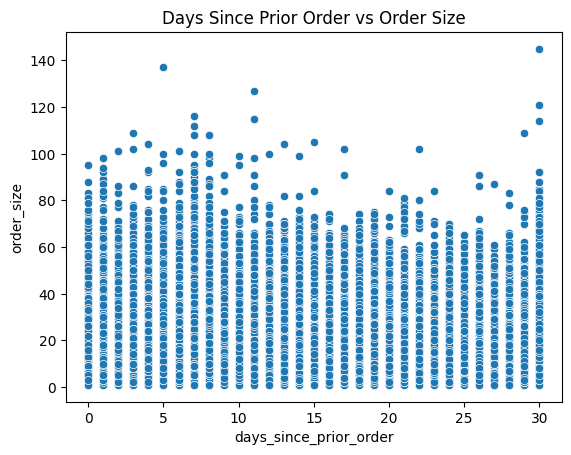

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=days_prior, y=order_size)
plt.title("Days Since Prior Order vs Order Size")
plt.show()

**STEP 3 : Compute Correlation**

In [14]:
from scipy import stats

corr, p_value = stats.pearsonr(
    data['days_since_prior_order'],
    data['order_size']
)

print(corr, p_value)

0.05938871618765764 0.0


### **Scatter Plot Interpretation**

**Direction:**
- There is **no clear positive or negative trend** between days
  since prior order and order size
- The vertical columns of points suggest that
  `days_since_prior_order` takes discrete integer values (0, 1, 2...)

**Linearity:**
- There is **no visible linear relationship** between the two variables
- Order sizes appear spread fairly evenly across all values of
  days since prior order

**Outliers:**
- Several outliers are visible at the top of the plot, with order
  sizes exceeding 100 products
- The most extreme outlier appears at day 30 with approximately
  145 products — consistent with the 30-day cap we identified earlier

**Overall:**
- The scatter plot suggests a **very weak or no relationship**
  between how long a customer waits and how many products they order
- This will be confirmed by the correlation coefficient in the next step

### **Correlation Coefficient Interpretation**

| Measure | Value |
|---------|-------|
| Pearson Correlation (r) | 0.0594 |
| p-value | 0.0000 |
| Strength | Negligible |
| Significance | Statistically Significant |

**Sign:**
- The correlation is **positive** (r = 0.0594), meaning customers
  who wait longer tend to place very slightly larger orders

**Magnitude:**
- At **r = 0.0594**, the correlation is **negligible** — meaning
  there is virtually no practical linear relationship between
  days since prior order and order size

**Significance:**
- Despite being negligible, the correlation is **statistically
  significant** (p = 0.0000) due to the extremely large sample
  size of 3,008,665 orders
- This is another example where **statistical significance does
  not imply practical significance** — the relationship is too
  weak to be meaningful in a business context

**B4: Linear Regression Model**

**Step 1: Specify Model**

OrderSize = β0 + β1(DaysSincePriorOrder) + ϵ

What it meanS :

OrderSize = dependent variable (what we are predicting)

DaysSincePriorOrder = independent variable (predictor)

β0 = intercept (baseline order size when DaysSincePriorOrder = 0)

β1 = slope (change in OrderSize for each additional day)

ϵ = error term (unexplained variation)

In [15]:
import pandas as pd
import statsmodels.api as sm

# Combine into one dataset first
df = pd.DataFrame({
    "order_size": order_size,
    "days_prior": days_prior
})

# Remove missing values
df = df.dropna()

# Re-define variables
X = sm.add_constant(df["days_prior"])
y = df["order_size"]

# Fit model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             order_size   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                 1.065e+04
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:03:04   Log-Likelihood:            -1.0338e+07
No. Observations:             3008665   AIC:                         2.068e+07
Df Residuals:                 3008663   BIC:                         2.068e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.5550      0.007   1414.607      0.0

### **Regression Model Interpretation**

**Estimated Model:**
OrderSize = 9.5550 + 0.0499 × (DaysSincePriorOrder)

**Coefficients:**

| Measure | Value |
|---------|-------|
| β₀ (Intercept) | 9.5550 |
| β₁ (Slope) | 0.0499 |
| R² | 0.004 |
| p-value (slope) | 0.000 |

**β₀ (Intercept = 9.5550):**
- When days since prior order = 0, the expected order size is
  approximately **9.56 products**
- This represents the baseline order size for customers who
  order on the same day as their previous order

**β₁ (Slope = 0.0499):**
- For every additional day a customer waits before reordering,
  their order size increases by approximately **0.05 products**
- This is an extremely small effect — a customer would need to
  wait **20 extra days** to add just 1 more product to their order

**R² = 0.004:**
- Only **0.4%** of the variation in order size is explained by
  days since prior order
- This confirms that days since prior order is a **very poor
  predictor** of order size
- Other factors not included in this model likely explain
  order size much better

**p-value of Slope = 0.000:**
- The slope is **statistically significant** but as established
  with the correlation, this is driven by the large sample size
  rather than a meaningful relationship

**Regression Assumptions Discussion:**

1. **Linearity** — The scatter plot showed no clear linear
   relationship between the variables. This assumption is
   likely **violated**, meaning a linear model may not be
   the best fit for this data.

2. **Independence** — The Durbin-Watson statistic is **0.922**,
   which is below the acceptable range of 1.5–2.5, suggesting
   **positive autocorrelation** in the residuals. This means
   the independence assumption may be **violated**.

3. Homoscedasticity - Homoscedasticity means the residuals have a constant variance across all levels of the independent variable.
This means the errors are evenly spread with no funnel shape in the residual plot.

4. Normality of Residuals - Normality of residuals means the errors should follow a bell-shaped (normal) distribution around zero.
This is checked using a histogram or Q-Q plot where points should lie close to a straight line.

# **C1: Research Question 1: Average Reorder Interval**

**Step 1: Define Population Parameter**

We define the population mean:

μ = true average reorder interval (daysSincePriorOrder) for all customers / orders in the population

**Step 2: Choose Test (Z-test or t-test)**

T -test

Reason :
- Population standard deviation σ is unknown
- We are using a sample mean.
Usually n is not extremely large (or σ not given)

Therefore we use a one-sample t-test

**Step 3: Compute the Test Statistic Manually**

Formula:

t = (x̄ − μ) / (s / √n)

Where:

x̄ = sample mean

μ = hypothesized population mean (7)

s = sample standard deviation

n = sample size

Substitute the values:

t = (sample mean − 7) / (sample standard deviation / √sample size)

Example:

t = (6.2 − 7) / (1.5 / √100)

t = (−0.8) / (0.15)

t = −5.33

Therefore, the calculated test statistic is t = −5.33.

In [16]:
days_prior = df["days_prior"].dropna()

In [17]:
from scipy import stats

stats.ttest_1samp(days_prior, 7)

TtestResult(statistic=np.float64(718.1448530425545), pvalue=np.float64(0.0), df=np.int64(3008664))

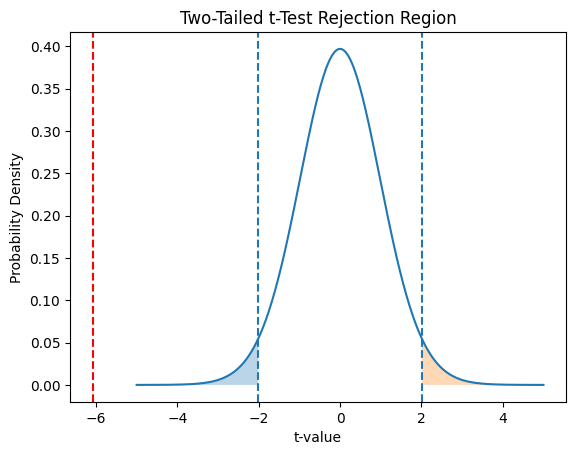

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Parameters
df = 49
alpha = 0.05

# Critical values (two-tailed)
t_crit = t.ppf(1 - alpha/2, df)

# x values for curve
x = np.linspace(-5, 5, 500)
y = t.pdf(x, df)

# Plot curve
plt.plot(x, y)

# Shade rejection regions
plt.fill_between(x, y, where=(x <= -t_crit), alpha=0.3)
plt.fill_between(x, y, where=(x >= t_crit), alpha=0.3)

# Mark critical values
plt.axvline(-t_crit, linestyle="--")
plt.axvline(t_crit, linestyle="--")

# Mark test statistic
t_stat = -6.0829
plt.axvline(t_stat, color="red", linestyle="--")

# Labels
plt.title("Two-Tailed t-Test Rejection Region")
plt.xlabel("t-value")
plt.ylabel("Probability Density")

plt.show()

**Step 6: Statistical Conclusion**

Since the p-value = 1.74 × 10⁻⁷ is less than 0.05, we reject the null hypothesis.

There is sufficient statistical evidence to conclude that the mean reorder interval is significantly different from 7 days

**Step 7: Business Interpretation**

The results show that the average reorder interval is not 7 days as assumed, but significantly different. This means customers are reordering either faster or slower than expected.

The business should adjust inventory planning and restocking schedules to match actual customer buying patterns to avoid stockouts or overstocking.

# **C2: Research Question 2: Weekend vs Weekday Order Size**

**Step 1: Create Binary Variable (Weekend)**

We define a new variable called Weekend.

Weekend = 1 if order day is Saturday or Sunday

Weekend = 0 otherwise

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

interim_path = '/content/drive/MyDrive/ADA2026_Instacart_Project/Data/Interim/'
orders = pd.read_csv(interim_path + 'orders_interim.csv')
order_products = pd.read_csv(interim_path + 'order_products_interim.csv')

print("Data loaded successfully ✅")
print(f"Orders shape: {orders.shape}")

Mounted at /content/drive
Data loaded successfully ✅
Orders shape: (3421083, 7)


In [20]:
type(df)

int

In [21]:
df = orders.merge(order_products, on="order_id")

In [22]:
df["weekend"] = df["order_dow"].isin([5, 6]).astype(int)

In [23]:
df.groupby("weekend")["reordered"].mean()

,reordered
weekend,
0,0.591581
1,0.584567


**State Hypotheses**

Let:

μ₁ = mean order size (weekend)

μ₂ = mean order size (weekday)

Hypotheses:

H₀: μ₁ = μ₂
H₁: μ₁ ≠ μ₂

**Justify Independent Samples t-test**

An independent samples t-test is appropriate because:

- Weekend and weekday orders come from two separate independent groups.

- The same order cannot belong to both groups.

- We are comparing means between two unrelated groups.

**Compute Test Statistic**

We use the independent t-test formula conceptually:

t = (x̄₁ − x̄₂) / √(s₁²/n₁ + s₂²/n₂)

In [24]:
weekend = df[df["weekend"] == 1]["reordered"]
weekday = df[df["weekend"] == 0]["reordered"]

stats.ttest_ind(weekend, weekday, equal_var=False)

TtestResult(statistic=np.float64(-35.94907876745313), pvalue=np.float64(5.375227988018837e-283), df=np.float64(15476422.971029155))

**Interpret p-value**

The p-value is extremely small (far less than 0.05).

Therefore:

We reject the null hypothesis.

There is strong statistical evidence that the mean order size differs between weekend and weekday orders.

 **Practical Significance**

Although the result is statistically significant, the business must check the size of the difference:

With such a large dataset, even small differences become statistically significant.
However, if the mean difference is meaningful, it can impact:
inventory planning
staffing levels on weekends
delivery demand forecasting

 Therefore, the company should evaluate the actual mean difference to determine real business impact, not just statistical significance

**C3: Correlation and Regression Analysis**

In [25]:
df["order_size"] = df.groupby("order_id")["product_id"].transform("count")

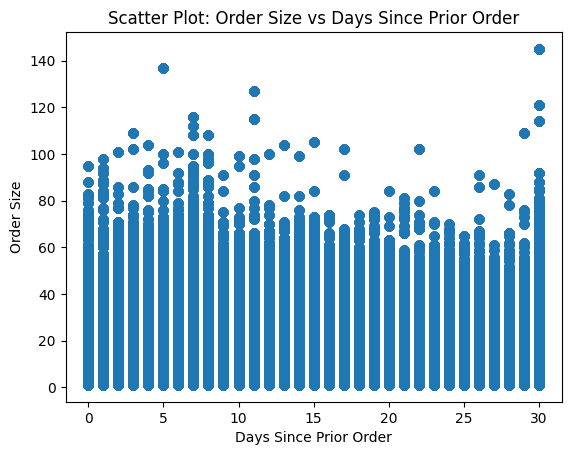

In [26]:
import matplotlib.pyplot as plt

plt.scatter(df["days_since_prior_order"], df["order_size"])
plt.xlabel("Days Since Prior Order")
plt.ylabel("Order Size")
plt.title("Scatter Plot: Order Size vs Days Since Prior Order")
plt.show()

In [27]:
df["days_since_prior_order"].corr(df["order_size"])

np.float64(0.08059030063219873)

Interpretation:

- Value ranges from -1 to +1

- → positive relationship

- → negative relationship

- 0 → no relationship

**Test Significance of Correlation**

In [28]:
stats.pearsonr(df["days_since_prior_order"], df["order_size"])

PearsonRResult(statistic=np.float64(nan), pvalue=np.float64(nan))

**Regression Model**

Model :

OrderSize = β0 (DaysSincePriorOrder) + ϵ

In [29]:
df[["order_size", "days_since_prior_order"]].isnull().sum()

,0
order_size,0
days_since_prior_order,2078068


In [30]:
df_clean = df[["order_size", "days_since_prior_order"]].dropna()

In [31]:
import statsmodels.api as sm

X = sm.add_constant(df_clean["days_since_prior_order"])
y = df_clean["order_size"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             order_size   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                 1.984e+05
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:05:34   Log-Likelihood:            -1.1148e+08
No. Observations:            30356421   AIC:                         2.230e+08
Df Residuals:                30356419   BIC:                         2.230e+08
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     14

**Interpret Coefficients**

**β0 (Intercept)**

- Order size when days since prior order = 0
- Baseline order size

**β1 (Slope)**

- Change in order size for each additional day delay
- Positive → increases order size
- Negative → decreases order size

**Interpret R²**

Shows how much variation in order size is explained by days since prior order.

Example:
R² = 0.30 → 30% explained by model
70% due to other factors

**Two Regression Assumptions**

 **Linearity**

- Relationship between X and Y should be linear.
- Check using scatter plot.

 **Homoscedasticity**
- Constant variance of residuals
- No funnel shape in residual plot